# Ensemble Technique
#### Random Forest Classifier

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits

In [3]:
# Creating the object of the class load_digits.

load_digits = load_digits()

# Getting its description.
print(load_digits.DESCR)

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

In [4]:
# The values in the dataset can be accessed by this
load_digits.data

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64))

In [5]:
# The column names in the datset can be accessed by this.

load_digits.feature_names

['pixel_0_0',
 'pixel_0_1',
 'pixel_0_2',
 'pixel_0_3',
 'pixel_0_4',
 'pixel_0_5',
 'pixel_0_6',
 'pixel_0_7',
 'pixel_1_0',
 'pixel_1_1',
 'pixel_1_2',
 'pixel_1_3',
 'pixel_1_4',
 'pixel_1_5',
 'pixel_1_6',
 'pixel_1_7',
 'pixel_2_0',
 'pixel_2_1',
 'pixel_2_2',
 'pixel_2_3',
 'pixel_2_4',
 'pixel_2_5',
 'pixel_2_6',
 'pixel_2_7',
 'pixel_3_0',
 'pixel_3_1',
 'pixel_3_2',
 'pixel_3_3',
 'pixel_3_4',
 'pixel_3_5',
 'pixel_3_6',
 'pixel_3_7',
 'pixel_4_0',
 'pixel_4_1',
 'pixel_4_2',
 'pixel_4_3',
 'pixel_4_4',
 'pixel_4_5',
 'pixel_4_6',
 'pixel_4_7',
 'pixel_5_0',
 'pixel_5_1',
 'pixel_5_2',
 'pixel_5_3',
 'pixel_5_4',
 'pixel_5_5',
 'pixel_5_6',
 'pixel_5_7',
 'pixel_6_0',
 'pixel_6_1',
 'pixel_6_2',
 'pixel_6_3',
 'pixel_6_4',
 'pixel_6_5',
 'pixel_6_6',
 'pixel_6_7',
 'pixel_7_0',
 'pixel_7_1',
 'pixel_7_2',
 'pixel_7_3',
 'pixel_7_4',
 'pixel_7_5',
 'pixel_7_6',
 'pixel_7_7']

In [6]:
# Once we know the data and column names in the dataset, we can create a data_frame out of it using this:

data_frame = pd.DataFrame(data=load_digits.data, columns=load_digits.feature_names)
data_frame.head(3)

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0


In [7]:
# This gives us the target column.

load_digits.target

# This column is not present on the dataset or the created data_frame. Therefore we must append it to out data_frame, giving it a suitable column name.

array([0, 1, 2, ..., 8, 9, 8], shape=(1797,))

In [8]:
# I just added a new column named 'number' and to it inserted the target values. Like this:

data_frame['number'] = load_digits.target
data_frame.head(3)

# You can scroll all the way to the right to see a new added column 'number' at the end 😁

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,number
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2


In [9]:
data_frame.info()

# See there are no null values. The dataset present in sklearn are mostly preprocessed. This saves us a lot of time doing EDA.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pixel_0_0  1797 non-null   float64
 1   pixel_0_1  1797 non-null   float64
 2   pixel_0_2  1797 non-null   float64
 3   pixel_0_3  1797 non-null   float64
 4   pixel_0_4  1797 non-null   float64
 5   pixel_0_5  1797 non-null   float64
 6   pixel_0_6  1797 non-null   float64
 7   pixel_0_7  1797 non-null   float64
 8   pixel_1_0  1797 non-null   float64
 9   pixel_1_1  1797 non-null   float64
 10  pixel_1_2  1797 non-null   float64
 11  pixel_1_3  1797 non-null   float64
 12  pixel_1_4  1797 non-null   float64
 13  pixel_1_5  1797 non-null   float64
 14  pixel_1_6  1797 non-null   float64
 15  pixel_1_7  1797 non-null   float64
 16  pixel_2_0  1797 non-null   float64
 17  pixel_2_1  1797 non-null   float64
 18  pixel_2_2  1797 non-null   float64
 19  pixel_2_3  1797 non-null   float64
 20  pixel_2_

In [ ]:
# Here we are splitting features and target column.
# Why did I use capital X?
# Because X is a collection of features x. Just a naming convention nothing more.


# Feature and Target column splitting is also know as vertical split. Just imagine you are seperating a data_frame vertically into features and target column. 

X = data_frame.iloc[:, : -1]
y = data_frame['number']

In [11]:
from sklearn.model_selection import train_test_split

In [ ]:
# train_test_split produces horizontal split. If you find this confusion, I am always one call/text away.

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42, test_size=0.2)
print(f"{X_train.shape, X_test.shape, y_train.shape, y_test.shape}")

((1437, 64), (360, 64), (1437,), (360,))


## Checking for missing values

In [ ]:
# This is just formality. We don't need to add this line in our practical.
# It is the same shit we did above when we executed data_fram.info()

print(data_frame.isnull().sum())

pixel_0_0    0
pixel_0_1    0
pixel_0_2    0
pixel_0_3    0
pixel_0_4    0
            ..
pixel_7_4    0
pixel_7_5    0
pixel_7_6    0
pixel_7_7    0
number       0
Length: 65, dtype: int64


No null values

## Checking for class imbalance

In [ ]:
# 'Class Imbalance'. We should check this before applying classification algorithms.
# When a class is imbalance, it simply means that our target column contains one class with maximum or just too many entries, while the other class contains too less entries. This makes it difficult for an ML algorithm to find patterns, and results in overfitting (ML algorithm memorizing the data without understanding the data).

print(y_train.value_counts())

number
1    146
3    146
5    145
6    145
4    145
9    144
7    143
0    142
2    142
8    139
Name: count, dtype: int64


Seems balanced

#### We must not rely on 'accuracy' score when the dataset is imbalanced.

## Decision Tree Classifier

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [ ]:
# random_state = Ensures the "random" splits are the same every time you run the code. 42 is a common convention in the ML community.
# max_depth = Limits how many layers deep the tree can grow. This is your primary defense against overfitting.

DT_classifier = DecisionTreeClassifier(random_state=42, max_depth=15)

# This prepares the model:
DT_classifier.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


<!-- Making predictions now. -->

In [ ]:
# Now make predictions on testing dataset and save it in a variable

DT_predicted_values = DT_classifier.predict(X_test)

Evaluation

In [ ]:
# Now find the various metric scores of testing dataset against the predicted values.


print("Decision Tree Results: ")
print(f"Accuracy: {accuracy_score(y_test, DT_predicted_values):.4}")
print(f"Precision: {precision_score(y_test, DT_predicted_values, average='weighted'):.4}")
print(f"Recall: {recall_score(y_test, DT_predicted_values, average='weighted'):.4}")
print(f"F1 Score: {f1_score(y_test, DT_predicted_values, average='weighted'):.4}")
print(f"\nClassification Report:\n {classification_report(y_test, DT_predicted_values)}")


Decision Tree Results: 
Accuracy: 0.825
Precision: 0.8241
Recall: 0.825
F1 Score: 0.8237

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95        36
           1       0.84      0.72      0.78        36
           2       0.78      0.80      0.79        35
           3       0.79      0.81      0.80        37
           4       0.86      0.86      0.86        36
           5       0.88      0.95      0.91        37
           6       0.81      0.83      0.82        36
           7       0.84      0.86      0.85        36
           8       0.71      0.69      0.70        35
           9       0.82      0.75      0.78        36

    accuracy                           0.82       360
   macro avg       0.82      0.82      0.82       360
weighted avg       0.82      0.82      0.82       360



## Random Forest Classifier

In [ ]:
# This is main. Random Forest is just a group od Decision Trees.

from sklearn.ensemble import RandomForestClassifier

In [ ]:
# n_estimators=100 = The number of trees in your forest. Generally, more trees provide better performance, but they take longer to train. 100 is a standard starting point.

# n_jobs=-1 = This is just a performance booster. This is an optional parameter. It tells to use all available CPU cores on our computer to build the trees in parallel. I have got 8 cores. How many do you have?

RF_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
RF_classifier.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Making predictions

In [22]:
RF_predicted_values = RF_classifier.predict(X_test)

Evaluation

In [23]:
print("\nRandom Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, RF_predicted_values):.4f}")
print(f"Precision: {precision_score(y_test, RF_predicted_values, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, RF_predicted_values, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, RF_predicted_values, average='weighted'):.4f}")
print("\nClassification Report:\n", classification_report(y_test, RF_predicted_values))


Random Forest Results:
Accuracy: 0.9611
Precision: 0.9620
Recall: 0.9611
F1-Score: 0.9609

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.90      0.97      0.93        36
           2       1.00      0.97      0.99        35
           3       0.97      0.97      0.97        37
           4       0.97      0.97      0.97        36
           5       0.97      1.00      0.99        37
           6       1.00      0.97      0.99        36
           7       0.92      1.00      0.96        36
           8       0.94      0.86      0.90        35
           9       0.97      0.92      0.94        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



Comparision

In [ ]:
# Just to see scores side-by-side.

print(f"\nDT Accuracy: {accuracy_score(y_test, DT_predicted_values):.4f}")
print(f"RF Accuracy: {accuracy_score(y_test, RF_predicted_values):.4f}")


DT Accuracy: 0.8250
RF Accuracy: 0.9611


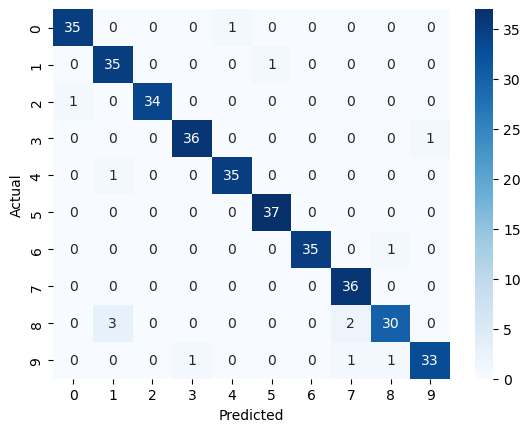

In [ ]:
# Now visualize the predictions made by the two models

cm = confusion_matrix(y_test, RF_predicted_values)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Congratulations on finishing the practical assignment 😄